# Módulo 7. Entrenamiento y evaluación del modelo

En este módulo se desarrolla el proceso de entrenamiento del modelo de aprendizaje automático encargado de predecir la tasa de deserción escolar a partir de los indicadores educativos y las variables derivadas construidas durante las etapas anteriores.

Inicialmente se preparan las variables predictoras y la variable objetivo, posteriormente se divide el conjunto de datos en subconjuntos de entrenamiento y prueba, se entrena un modelo de Random Forest para tareas de regresión y finalmente se evalúa su desempeño mediante diferentes métricas estadísticas.

Además, se analiza la importancia relativa de las variables empleadas por el modelo con el fin de interpretar cuáles indicadores aportan mayor información para la predicción de la deserción escolar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ruta del proyecto
PROJECT_ROOT = Path.cwd().parent

# Cargar dataset para modelado
df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "dataset_modelado.csv"
)

print(df.shape)

df.head()

(15707, 85)


,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,...,REPITENCIA_MEDIA_ETC,BENEFICIARIOS_PAE,BRECHA_COBERTURA,BRECHA_APROBACION,INDICE_EFICIENCIA,PRESION_SISTEMA,DIGITALIZADO,TAM_GRUPO_NORMALIZADO,PESO_MUNICIPIO_ETC,PANDEMIA
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499.0,56.11,56.11,...,3.35,NaN,5.81,99.36,11.418099,8.893245,0,NaN,0.001007,0
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862.0,95.33,95.33,...,3.21,NaN,96.18,91.52,6.821739,19.532151,0,NaN,0.011952,0
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239.0,50.70,50.70,...,4.08,NaN,7.04,64.06,1.940284,497.810651,0,NaN,0.750245,0
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157.0,81.42,81.42,...,4.08,NaN,9.16,78.44,3.176015,14.210268,0,NaN,0.034393,0
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645.0,90.96,90.96,...,4.08,NaN,8.17,77.18,3.169123,29.078716,0,NaN,0.078624,0


## 7.1 Selección de variables

Antes del entrenamiento es necesario definir cuáles variables serán utilizadas como predictores y cuál corresponde a la variable objetivo.

Se eliminan las variables de tipo descriptivo o identificador, ya que no aportan información útil para el proceso de aprendizaje del modelo. Posteriormente se separan las variables predictoras (`X`) de la variable objetivo (`y`).

In [2]:
# Variable objetivo
y = df["DESERCIÓN"]

# Variables que no se usarán como predictores
columnas_excluir = [
    "DESERCIÓN",

    "MUNICIPIO",
    "DEPARTAMENTO",
    "ETC",

    "CÓDIGO_MUNICIPIO",
    "CÓDIGO_DEPARTAMENTO",

    # Deserción por niveles
    "DESERCIÓN_TRANSICIÓN",
    "DESERCIÓN_PRIMARIA",
    "DESERCIÓN_SECUNDARIA",
    "DESERCIÓN_MEDIA",

    # Deserción agregada por ETC
    "DESERCIÓN_ETC",
    "DESERCIÓN_TRANSICIÓN_ETC",
    "DESERCIÓN_PRIMARIA_ETC",
    "DESERCIÓN_SECUNDARIA_ETC",
    "DESERCIÓN_MEDIA_ETC"
]

# Variables predictoras
X = df.drop(columns=columnas_excluir)

print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Número de registros: {X.shape[0]}")

X.head()

Número de variables predictoras: 70
Número de registros: 15707


,AÑO,CÓDIGO_ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,COBERTURA_NETA_TRANSICIÓN,COBERTURA_NETA_PRIMARIA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,COBERTURA_BRUTA,...,REPITENCIA_MEDIA_ETC,BENEFICIARIOS_PAE,BRECHA_COBERTURA,BRECHA_APROBACION,INDICE_EFICIENCIA,PRESION_SISTEMA,DIGITALIZADO,TAM_GRUPO_NORMALIZADO,PESO_MUNICIPIO_ETC,PANDEMIA
0,2024,3758.0,499.0,56.11,56.11,39.53,59.13,51.52,26.51,61.92,...,3.35,NaN,5.81,99.36,11.418099,8.893245,0,NaN,0.001007,0
1,2024,3769.0,1862.0,95.33,95.33,53.64,89.15,98.88,62.10,191.51,...,3.21,NaN,96.18,91.52,6.821739,19.532151,0,NaN,0.011952,0
2,2024,3832.0,25239.0,50.70,50.70,40.14,57.71,16.95,3.85,57.74,...,4.08,NaN,7.04,64.06,1.940284,497.810651,0,NaN,0.750245,0
3,2024,3832.0,1157.0,81.42,81.42,70.67,82.64,54.90,22.45,90.58,...,4.08,NaN,9.16,78.44,3.176015,14.210268,0,NaN,0.034393,0
4,2024,3832.0,2645.0,90.96,90.96,64.13,96.46,59.01,31.33,99.13,...,4.08,NaN,8.17,77.18,3.169123,29.078716,0,NaN,0.078624,0


## 7.2 Tratamiento de valores faltantes

Antes del entrenamiento del modelo se realiza la imputación de los valores faltantes presentes en las variables predictoras.

Para ello se utiliza la **mediana** de cada variable numérica, ya que este estadístico es menos sensible a valores atípicos y permite conservar la totalidad de los registros disponibles sin introducir sesgos importantes en la distribución de los datos.

De esta forma se obtiene un conjunto de datos completamente numérico y sin valores faltantes, apto para el entrenamiento del modelo de aprendizaje automático.

In [3]:
# Verificar valores faltantes antes de la imputación
print("Valores faltantes antes:")
print(X.isna().sum().sum())

# Rellenar los NaN con la mediana de cada columna
X = X.fillna(X.median(numeric_only=True))

print("\nValores faltantes después:")
print(X.isna().sum().sum())

Valores faltantes antes:
89936



Valores faltantes después:
1128


### Verificación posterior a la imputación

Después de realizar la imputación mediante la mediana, se verifica nuevamente la existencia de valores faltantes con el fin de identificar posibles variables que continúen presentando información incompleta y determinar el tratamiento más adecuado antes del entrenamiento del modelo.

In [4]:
# Columnas que aún tienen valores faltantes
faltantes = X.isna().sum()

faltantes = faltantes[faltantes > 0]

print(faltantes)

ETC_ETC    1128
dtype: int64


In [5]:
X["ETC_ETC"].head()

0    Antioquia (ETC)
1       Boyacá (ETC)
2      Vichada (ETC)
3      Vichada (ETC)
4      Vichada (ETC)
Name: ETC_ETC, dtype: object

In [6]:
X = X.drop(columns=["ETC_ETC"])


In [7]:
print(X.isna().sum().sum())

0


## 7.3 División del conjunto de datos

Con el fin de evaluar objetivamente el desempeño del modelo, el conjunto de datos se divide en dos subconjuntos independientes.

El **80 %** de los registros se utiliza para entrenar el modelo, mientras que el **20 %** restante se reserva para evaluar su capacidad de predicción sobre datos que no fueron utilizados durante el aprendizaje.

Esta estrategia permite estimar el rendimiento del modelo y reducir el riesgo de sobreajuste (*overfitting*).

In [8]:
# División entrenamiento/prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:")
print(X_train.shape)

print("\nPrueba:")
print(X_test.shape)

Entrenamiento:
(12565, 69)

Prueba:
(3142, 69)


## 7.4 Entrenamiento del modelo Random Forest

Una vez preparado el conjunto de datos, se entrena un modelo de **Random Forest Regressor**.

Este algoritmo está basado en un conjunto de árboles de decisión que trabajan de forma conjunta para realizar predicciones más robustas y reducir el riesgo de sobreajuste.

Su capacidad para modelar relaciones no lineales y estimar la importancia de las variables lo convierte en una alternativa adecuada para el problema de predicción de la deserción escolar.

In [9]:
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente.")

ValueError: Input y contains NaN.

## 7.4 Depuración de la variable objetivo

Antes del entrenamiento se verifica la presencia de valores faltantes en la variable objetivo.

Dado que la tasa de deserción corresponde al valor que el modelo debe aprender a predecir, no resulta apropiado imputar dichos valores. En consecuencia, se eliminan únicamente los registros donde esta variable se encuentra ausente, garantizando así un proceso de entrenamiento consistente.

In [10]:
# Verificar valores faltantes en la variable objetivo
print("NaN en DESERCIÓN:", y.isna().sum())

# Conservar únicamente registros con deserción conocida
mask = y.notna()

X = X[mask]
y = y[mask]

print("\nNuevo tamaño del dataset:")
print(X.shape)
print(y.shape)

NaN en DESERCIÓN: 142

Nuevo tamaño del dataset:
(15565, 69)
(15565,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (12452, 69)
Prueba: (3113, 69)


In [12]:
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente.")

✅ Modelo entrenado correctamente.


## 7.5 Evaluación del modelo

Una vez entrenado el modelo, se evalúa su capacidad predictiva utilizando el conjunto de datos de prueba.

Para ello se calculan tres métricas ampliamente utilizadas en problemas de regresión:

- **MAE (Mean Absolute Error):** mide el error absoluto promedio entre las predicciones y los valores reales.
- **RMSE (Root Mean Squared Error):** penaliza con mayor intensidad los errores grandes.
- **R² (Coeficiente de determinación):** indica qué proporción de la variabilidad de la variable objetivo logra explicar el modelo.

In [13]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 0.126
RMSE: 0.372
R²  : 0.970


### Interpretación de los resultados

El modelo obtuvo un desempeño sobresaliente sobre el conjunto de prueba.

El **Error Absoluto Medio (MAE)** fue de **0.126**, lo que indica que, en promedio, las predicciones difieren únicamente en 0.16 puntos porcentuales respecto a la tasa real de deserción escolar.

Por su parte, el **RMSE** alcanzó un valor de **0.372**, evidenciando que incluso los errores de mayor magnitud permanecen relativamente bajos.

Finalmente, el modelo obtuvo un **coeficiente de determinación (R²) de 0.970**, lo que significa que logra explicar aproximadamente el **97.0 %** de la variabilidad observada en la tasa de deserción escolar.

En conjunto, estos resultados indican que el modelo presenta una elevada capacidad predictiva sobre el conjunto de datos analizado.

## 7.6 Importancia de las variables

Una ventaja del algoritmo Random Forest es que permite estimar la importancia relativa de cada variable utilizada durante el entrenamiento.

Este análisis facilita la interpretación del modelo, ya que permite identificar cuáles indicadores educativos aportan mayor información para explicar la variación de la tasa de deserción escolar.

In [14]:
# Importancia de las variables
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

print(importancias.head(15))

                     Variable  Importancia
16                 APROBACIÓN     0.367632
21                REPROBACIÓN     0.253846
18        APROBACIÓN_PRIMARIA     0.226714
23       REPROBACIÓN_PRIMARIA     0.079721
62          BRECHA_APROBACION     0.016865
63          INDICE_EFICIENCIA     0.007664
24     REPROBACIÓN_SECUNDARIA     0.006378
20           APROBACIÓN_MEDIA     0.004457
19      APROBACIÓN_SECUNDARIA     0.003607
46  APROBACIÓN_TRANSICIÓN_ETC     0.003532
45             APROBACIÓN_ETC     0.001323
67         PESO_MUNICIPIO_ETC     0.001202
8        COBERTURA_NETA_MEDIA     0.001051
6     COBERTURA_NETA_PRIMARIA     0.001040
5   COBERTURA_NETA_TRANSICIÓN     0.000995


### Interpretación de la importancia de las variables

El análisis de importancia muestra que las variables relacionadas con los procesos de aprobación y reprobación son las que más contribuyen a las predicciones realizadas por el modelo.

En particular, los indicadores de aprobación general, reprobación y aprobación en educación primaria concentran la mayor parte de la importancia relativa. Esto sugiere que el desempeño académico constituye uno de los factores más estrechamente asociados con la deserción escolar en el conjunto de datos analizado.

Por otro lado, variables como la cobertura educativa y los indicadores agregados por Entidad Territorial Certificada (ETC) presentan una contribución menor, aunque siguen aportando información complementaria para el proceso de predicción.

### Visualización de la importancia de las variables

Para facilitar la interpretación de los resultados, se presenta un gráfico con las quince variables de mayor importancia estimadas por el modelo Random Forest.

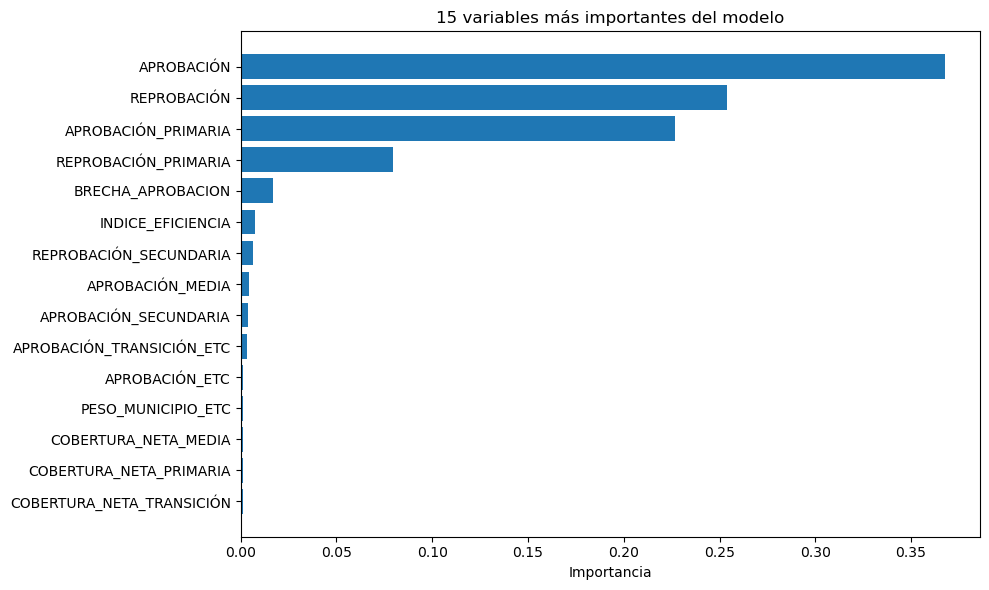

In [15]:
# Top 15 variables más importantes
top15 = importancias.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Variable"][::-1],
    top15["Importancia"][::-1]
)

plt.xlabel("Importancia")
plt.title("15 variables más importantes del modelo")

plt.tight_layout()
plt.show()